In [1]:
from astropy.io import fits
import pyregion
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as cte 
import regions
from astropy.wcs import WCS
import cmasher as cm
import seaborn as sn
#from discrete_gaussian_model import DiscreteGaussianModel
from astropy.nddata import Cutout2D
from astropy.coordinates import Angle
from astropy.modeling import models, fitting
from astropy.modeling.models import Const1D
from astropy.table import QTable, Table
from astropy.coordinates import SkyCoord
FITTER = fitting.LevMarLSQFitter()

/home/roberto/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
'''Primero cargamos las ubicacionees de los globules que se encuentran en la carpeta M1-67'''
regs = regions.Regions.read('/home/roberto/MAST_2026-07-31T01_03_53.583Z/Globules_001.reg', format="ds9")
regs = [_ for _ in regs if hasattr(_, 'center') and _.visual.get('marker') == "o"]
len(regs)

2

In [3]:
source_table = QTable(
    [
        {"ICRS": r.center, "Isolated": r.visual.get('markeredgewidth') == 3} 
        for r in regs
    ]
)
source_table

ICRS,Isolated
"deg,deg",
SkyCoord,bool
"84.66330208333332,-69.09784805555554",False
"84.65894041666665,-69.10113638888889",False


Set DATE-AVG to '2022-06-03T00:38:36.813' from MJD-AVG.
Set DATE-END to '2022-06-03T03:29:02.366' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.382178 from OBSGEO-[XYZ].
Set OBSGEO-H to 1651545788.871 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


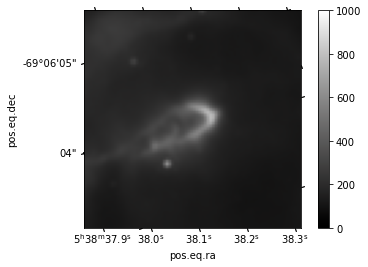

In [16]:
'''Aqui mostramos como se deberiain de ver'''
filter_ = fits.open('/home/roberto/MAST_2026-07-31T01_03_53.583Z/MAST_2026-08-14T16_49_24.413Z/JWST/jw02729-o001_t001_nircam_clear-f187n_i2d.fits')
hdu = filter_['SCI']
wcs = WCS(hdu)

j1, i1 = wcs.world_to_array_index(source_table[1]['ICRS'])
size = 40
yslice, xslice = slice(j1 - size, j1 + size), slice(i1 - size, i1 + size)
cutout = hdu.data[yslice, xslice]
wcutout = wcs.slice((yslice, xslice))

fig = plt.figure()
ax = fig.add_subplot(projection=wcutout)
im = ax.imshow(cutout, vmin=0.0, cmap=cm.neutral,vmax=1000)
cb = fig.colorbar(im, ax=ax)
#ax.set_title(f"PA = {source_table[0]['PA']:.1f}, separation = {source_table[0]['Sep']:.1f}")
...;

In [7]:
c0 = SkyCoord.from_name('R136a', cache=True)
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.68041667, -69.10222222)>

In [48]:
#cen = SkyCoord("05h38m42.4s", "-69d06m03s", frame="icrs")
cen = SkyCoord("05h38m42.7500s","-69d06m03.781s", frame="icrs")
cen

<SkyCoord (ICRS): (ra, dec) in deg
    (84.678125, -69.10105028)>

In [49]:
source_table["PA"] = cen.position_angle(source_table["ICRS"]).to(u.deg)
source_table["Sep"] = source_table["ICRS"].separation(cen).to(u.arcsec)
source_table["PA"].info.format = ".2f"
source_table["Sep"].info.format = ".2f"

In [61]:
class SourceCutout:
    """Small image cut out around a given source
    """
    
    def __init__(self, pdata, hdu, size=3.5 * u.arcsec):
        self.center = pdata["ICRS"]
        # PA of source wrt star
        self.pa_source = pdata["PA"]
        # and PA of star wrt source
        self.pa_star = Angle(self.pa_source + 180 * u.deg).wrap_at(360 * u.deg)
        self.sep = pdata["Sep"]
        self.is_isolated = pdata["Isolated"]
        self.size = size
        self.cutout = Cutout2D(
            hdu.data, position=self.center, size=size, wcs=WCS(hdu), copy=True,
        )
        self.image = self.cutout.data
        self.wcs = self.cutout.wcs
        ny, nx = self.image.shape
        self.x, self.y = np.meshgrid(np.arange(nx), np.arange(ny))
        self.image_coords = self.wcs.pixel_to_world(self.x, self.y)
        # Radius and PA of each pixel with respect to the NOMINAL center
        self.r = self.center.separation(self.image_coords)
        self.pa = self.center.position_angle(self.image_coords)
        # Default mask has max radius of half the cutout size
        self.set_mask(r_out=self.size / 2)

        self.find_bary_center()
        # Recalculate r, pa, and masks wrt the barycenter
        self.r = self.barycenter.separation(self.image_coords)
        self.pa = self.barycenter.position_angle(self.image_coords)
        self.set_mask(r_out=self.size / 2)

        # And do photometry
        self.bright_peak = np.max(self.image[self.coremask])
        # Take the 10% centile as estimate of BG value
        self.bright_bg = np.percentile(
            self.image[self.mask],
            10,
        )
        # BG-subtracted of the core region
        self.flux_core = np.sum((self.image - self.bright_bg)[self.coremask])
        # BG-subtracted part of the outer part within the mask but excluding core
        self.flux_halo = np.sum(
            (self.image - self.bright_bg)[(~self.coremask) & self.mask]
            )

        
    def __repr__(self):
        return f"SourceCutout({self.pa_source:.1f}, {self.sep:.1f})"
       
         
    def set_mask(
        self,
        r_out = 3.0 * u.arcsec,
        r_in = 0.2 * u.arcsec,
        r_core = 0.2 * u.arcsec,
        mu_min = 0.5,
    ):
        cth = np.cos((self.pa - self.pa_star))
        self.mask = (self.r <= r_out) & ((cth >= mu_min) | (self.r <= r_in))
        self.coremask = (self.r <= r_in)

    def find_bary_center(self):
        """Refine estimate of center by using flux-weighted mean
        position within the core mask
        """
        m = self.coremask

        # Original version was flux-weighted mean
        # xbary = np.average(self.x[m], weights=self.image[m])
        # ybary = np.average(self.x[m], weights=self.image[m])

        # New version is just the peak pixel
        index = np.argmax(self.image[m], axis=None)
        xbary = self.x[m][index]
        ybary = self.y[m][index]

        self.barycenter = self.wcs.pixel_to_world(xbary, ybary)



In [62]:
source = source_table[1]
cutout = SourceCutout(source, hdu)

Set DATE-AVG to '2022-06-03T00:38:36.813' from MJD-AVG.
Set DATE-END to '2022-06-03T03:29:02.366' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.382178 from OBSGEO-[XYZ].
Set OBSGEO-H to 1651545788.871 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


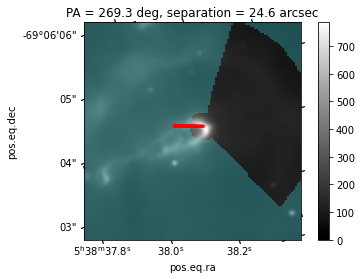

In [70]:
fig = plt.figure()
ax = fig.add_subplot(projection=cutout.wcs)
im = ax.imshow(
    cutout.image,
    vmin=0.0, 
    cmap=cm.neutral,
    )
cb = fig.colorbar(im, ax=ax)
ax.imshow(np.where(cutout.mask, np.nan, 1.0), vmin=0, vmax=1, cmap=cm.gem, alpha=0.3)
y1, x1 = cutout.wcs.world_to_array_index(cutout.barycenter)
arrow_length = 15.0
dx, dy = -arrow_length * np.sin(cutout.pa_star), arrow_length * np.cos(cutout.pa_star)
ax.arrow(x1, y1, dx, dy, color='r', lw=3)
ax.set_title(f"PA = {cutout.pa_source:.1f}, separation = {cutout.sep:.1f}")
...;

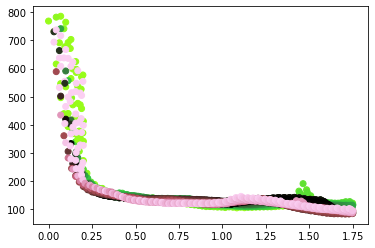

In [64]:
fig, ax = plt.subplots()
m = cutout.mask
ax.scatter(
    cutout.r[m].arcsec, 
    cutout.image[m], 
    c=Angle(cutout.pa - cutout.pa_star).wrap_at(180*u.deg).deg[m], 
    vmin=-60, vmax=60,
    cmap=cm.watermelon)

In [65]:
cutouts = [SourceCutout(source, hdu) for source in source_table]


Set DATE-AVG to '2022-06-03T00:38:36.813' from MJD-AVG.
Set DATE-END to '2022-06-03T03:29:02.366' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.382178 from OBSGEO-[XYZ].
Set OBSGEO-H to 1651545788.871 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-06-03T00:38:36.813' from MJD-AVG.
Set DATE-END to '2022-06-03T03:29:02.366' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.382178 from OBSGEO-[XYZ].
Set OBSGEO-H to 1651545788.871 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


# Fitting model

In [66]:
from astropy.modeling import models, fitting
from astropy.modeling.models import Const1D
FITTER = fitting.LevMarLSQFitter()
from discrete_gaussian_model import DiscreteGaussianModel

In [67]:
def fit_to_cutout(cutout):
    g0 = DiscreteGaussianModel(
        amplitude=300.0, mean=0.0, stddev=0.1, 
        bin_width=0.06, fixed={"bin_width": True},
        #0.1 for HST, 0.06 for F187N
        )
    g0.mean.fixed = True
    g0.stddev.bounds = 0.01, 0.5
    g0.amplitude.bounds = 0.01, 1000.0

    g1 = DiscreteGaussianModel(
        amplitude=300.0, mean=1.5, stddev=0.2,
        bin_width=0.06, fixed={"bin_width": True},
        )
    g1.mean.bounds = 0.1, 1.7
    g1.stddev.bounds = 0.01, 1.0
    g1.amplitude.bounds = 0.01, 300.0

    c0 = Const1D(amplitude=cutout.bright_bg)
    c0.amplitude.bounds = 0.0, 1.5 * cutout.bright_bg

    model = g0 + g1 + c0
    m = cutout.mask
    r = cutout.r[m].arcsec
    b = cutout.image[m]
    th = Angle(cutout.pa - cutout.pa_star).wrap_at(180*u.deg)[m]
    w = np.cos(th)**2 / (0.3 + r)**2

    cutout.fitted = FITTER(model, r, b, weights=w)
    cutout.core_sigma = cutout.fitted.stddev_0.value
    cutout.shell_radius = cutout.fitted.mean_1.value
    cutout.shell_sigma = cutout.fitted.stddev_1.value
    cutout.core_peak = cutout.fitted[0](0.0)
    cutout.shell_peak = cutout.fitted[1](cutout.shell_radius)
    cutout.bg_fit_level = cutout.fitted.amplitude_2.value

In [68]:
cutout = cutouts[0]
fit_to_cutout(cutout)

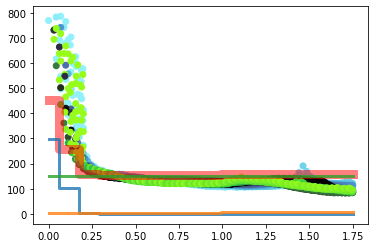

In [69]:
fig, ax = plt.subplots()
ax.scatter(
    cutout.r[m].arcsec, 
    cutout.image[m], 
    c=Angle(cutout.pa - cutout.pa_star).wrap_at(180*u.deg).deg[m], 
    vmin=-60, vmax=60,
    cmap=cm.seaweed)
rgrid = np.linspace(0.0, 1.75, 16)
ax.plot(rgrid, cutout.fitted(rgrid), drawstyle="steps-mid", linewidth=9, c='r', alpha=0.5)
for component in cutout.fitted:
    ax.plot(rgrid, component(rgrid), drawstyle="steps-mid", linewidth=3, alpha=0.8)

In [72]:
for cutout in cutouts:
    fit_to_cutout(cutout)

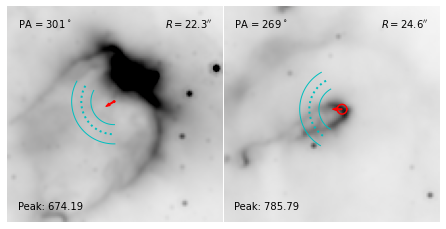

In [75]:
fig = plt.figure(figsize=(6, 6))
for idx, cutout in enumerate(cutouts):
    ax = fig.add_subplot(1, 2, idx + 1)
    im = ax.imshow(
        cutout.image, 
        vmin=0.5 * cutout.bright_bg,  
        vmax=max(cutout.bright_peak, 2 * cutout.shell_peak) + cutout.bright_bg, 
        cmap=cm.neutral_r, 
        origin='lower',
        )
    x1, y1 = cutout.wcs.world_to_pixel(cutout.barycenter)
    arrow_length = 5.0
    dx, dy = -arrow_length * np.sin(cutout.pa_star), arrow_length * np.cos(cutout.pa_star)
    ax.arrow(x1, y1, dx, dy, color='r', width=0.5, head_width=1.5, length_includes_head=True, )

    # Plot the sigma of core peak as circle
    angles = np.linspace(0, 360, 100) * u.deg
    rcore = cutout.core_sigma / 0.031 # in pixels
    x = x1 + rcore * np.cos(angles)
    y = y1 + rcore * np.sin(angles)
    ax.plot(x, y, color='r')

    # Plot the shell
    angles = np.linspace(
        cutout.pa_star - 60 * u.deg, 
        cutout.pa_star + 60 * u.deg, 
        100,
        )
    if cutout.shell_peak > 0.1 and cutout.shell_sigma/2 < cutout.shell_radius:
        for shift, ls, lw in zip([-1, 0, 1], ["-", ":", "-"], [1, 2, 1]):
            rshell = (cutout.shell_radius 
                      + shift * cutout.shell_sigma/2) / 0.1
            x = x1 - rshell * np.sin(angles)
            y = y1 + rshell * np.cos(angles)
            ax.plot(x, y, color='c', lw=lw, ls=ls)

    ax.text(0.05, 0.95, rf'PA = {round(cutout.pa_source.value):03d}$^\circ$', transform=ax.transAxes, va="top", ha="left")
    ax.text(0.95, 0.95, rf"$R = {cutout.sep.value:.1f}''$", transform=ax.transAxes, va="top", ha="right")
    ax.text(0.05, 0.05, rf"Peak: {cutout.bright_peak:.2f}", transform=ax.transAxes, va="bottom", ha="left")

    ax.set(xlabel="", ylabel="", xticks=[], yticks=[])
sn.despine(left=True, bottom=True)
fig.tight_layout(pad=0, h_pad=0.1, w_pad=0.1)
...;